In [8]:
import sys
from pathlib import Path
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline

# Add the project root to Python path
project_root = Path(__file__).parent.parent if '__file__' in globals() else Path.cwd().parent
sys.path.append(str(project_root))

# ML toolbox imports
from ml_toolbox.data_loader import DataLoader, create_windows_for_ml, create_label_to_class_map, extract_features_for_ml, FeatureConfig
from ml_toolbox.analysis.model_evaluation import evaluate_model_cv, cv_shap

# Initialize dataset manager
dataset_path = project_root / "data_set_4"

# Load files (DataLoader supports multi-value filters)
data_loader = DataLoader(dataset_path)
data, metadata = data_loader.load_batch(
    sensor_types="current",
    # frequencies=20,
    # loads=0
)

# Create windows
windows, labels, win_metadata = create_windows_for_ml(
    data_list=data,
    metadata_list=metadata,
    window_size=48000,
    max_windows_per_class=400,
)

# Extract features
feat_conf = FeatureConfig.for_sensor("current")
feat_conf.frequency_domain = True
feat_conf.hilbert_envelope = False
feat_conf.cross_channel = False
features, feature_names = extract_features_for_ml(
    windows, 
    metadata_list=win_metadata,
    sensor_type="current",
    feature_config=feat_conf
)

# Evaluate model
# Create pipeline
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('rf', RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        max_depth=10,
        min_samples_split=5,
        min_samples_leaf=2
    ))
])
eval_res = evaluate_model_cv(pipeline, features, labels)
shap_res = cv_shap(pipeline, features, labels)

INFO:ml_toolbox.data_loader.data_loader:Loading 64 files with 4 workers


INFO:ml_toolbox.data_loader.data_loader:Successfully loaded 64 files
INFO:ml_toolbox.data_loader.windowing:Class 'd0': selected 400 of 1904 available windows
INFO:ml_toolbox.data_loader.windowing:Class 'd3': selected 400 of 1904 available windows
INFO:ml_toolbox.data_loader.windowing:Class 'd6': selected 400 of 1904 available windows
INFO:ml_toolbox.data_loader.windowing:Class 'd9': selected 400 of 1904 available windows


Evaluating model (features: (1600, 26), samples: 1600)...
Mean CV Accuracy: 0.793 ± 0.018
Precision: 0.794, Recall: 0.793, F1: 0.794


 98%|===================| 1249/1280 [00:11<00:00]       

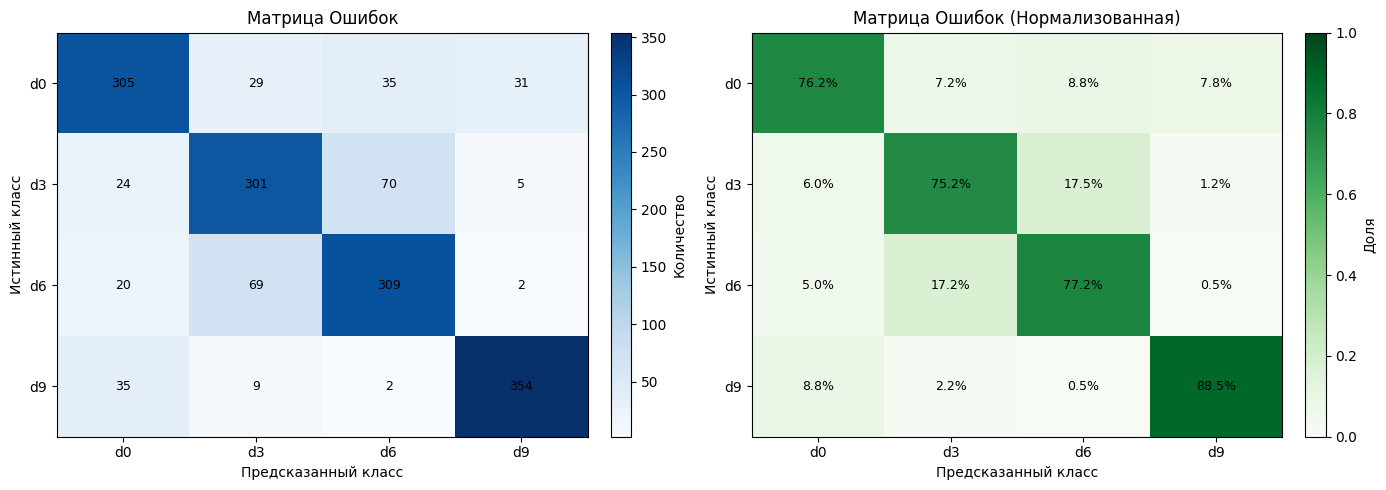

Per-class CV metrics:
Class d0: P=0.794, R=0.762, F1=0.778
Class d3: P=0.738, R=0.752, F1=0.745
Class d6: P=0.743, R=0.772, F1=0.757
Class d9: P=0.903, R=0.885, F1=0.894


In [9]:
# Confusion Matrix (Out of Fold CV Predictions)
import numpy as np
import matplotlib.pyplot as plt

cm = np.asarray(eval_res["confusion_matrix"], dtype=float)
label_to_class = create_label_to_class_map(win_metadata)
labels_order = [label_to_class.get(int(lbl), str(lbl)) for lbl in eval_res["unique_labels"]]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Raw counts
im0 = axes[0].imshow(cm, cmap="Blues", aspect="auto")
axes[0].set_title(f"Матрица Ошибок")
axes[0].set_xlabel("Предсказанный класс")
axes[0].set_ylabel("Истинный класс")
axes[0].set_xticks(np.arange(len(labels_order)))
axes[0].set_yticks(np.arange(len(labels_order)))
axes[0].set_xticklabels(labels_order)
axes[0].set_yticklabels(labels_order)
plt.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04, label="Количество")

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        axes[0].text(j, i, f"{int(cm[i, j])}", ha="center", va="center", color="black", fontsize=9)

# Row-normalized percentages (per true class)
row_sums = cm.sum(axis=1, keepdims=True)
cm_norm = np.divide(cm, row_sums, out=np.zeros_like(cm), where=row_sums != 0)

im1 = axes[1].imshow(cm_norm, cmap="Greens", aspect="auto", vmin=0.0, vmax=1.0)
axes[1].set_title("Матрица Ошибок (Нормализованная)")
axes[1].set_xlabel("Предсказанный класс")
axes[1].set_ylabel("Истинный класс")
axes[1].set_xticks(np.arange(len(labels_order)))
axes[1].set_yticks(np.arange(len(labels_order)))
axes[1].set_xticklabels(labels_order)
axes[1].set_yticklabels(labels_order)
plt.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04, label="Доля")

for i in range(cm_norm.shape[0]):
    for j in range(cm_norm.shape[1]):
        axes[1].text(j, i, f"{cm_norm[i, j] * 100:.1f}%", ha="center", va="center", color="black", fontsize=9)

plt.tight_layout()
plt.show()

print("Per-class CV metrics:")
for idx, class_label in enumerate(labels_order):
    print(
        f"Class {class_label}: "
        f"P={eval_res['precision_per_class'][idx]:.3f}, "
        f"R={eval_res['recall_per_class'][idx]:.3f}, "
        f"F1={eval_res['f1_per_class'][idx]:.3f}"
    )

=== SHAP Analysis ===
Number of CV folds: 5
Classification type: Multiclass (4 classes)


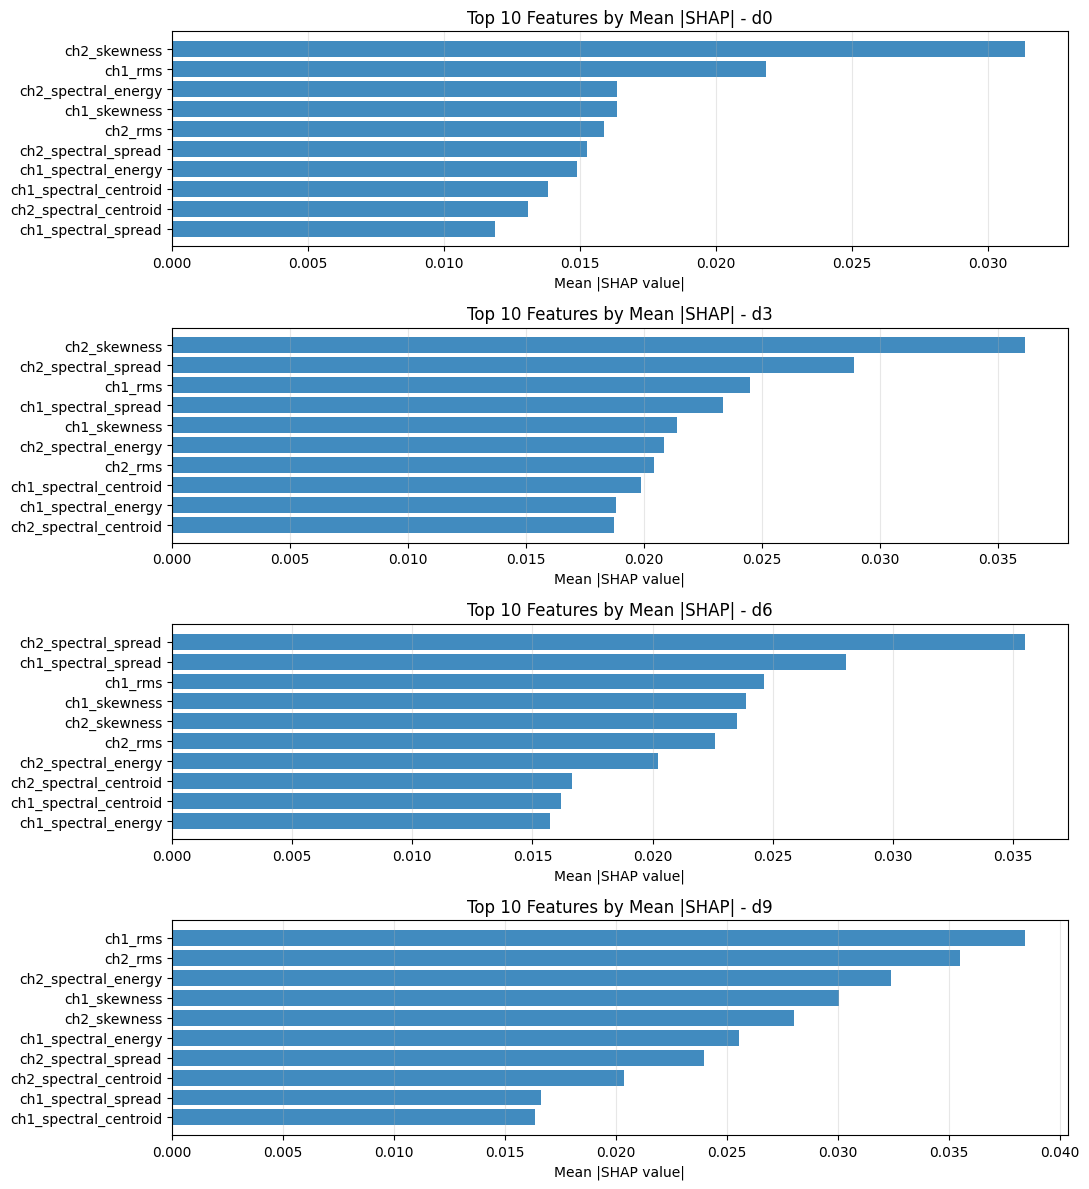

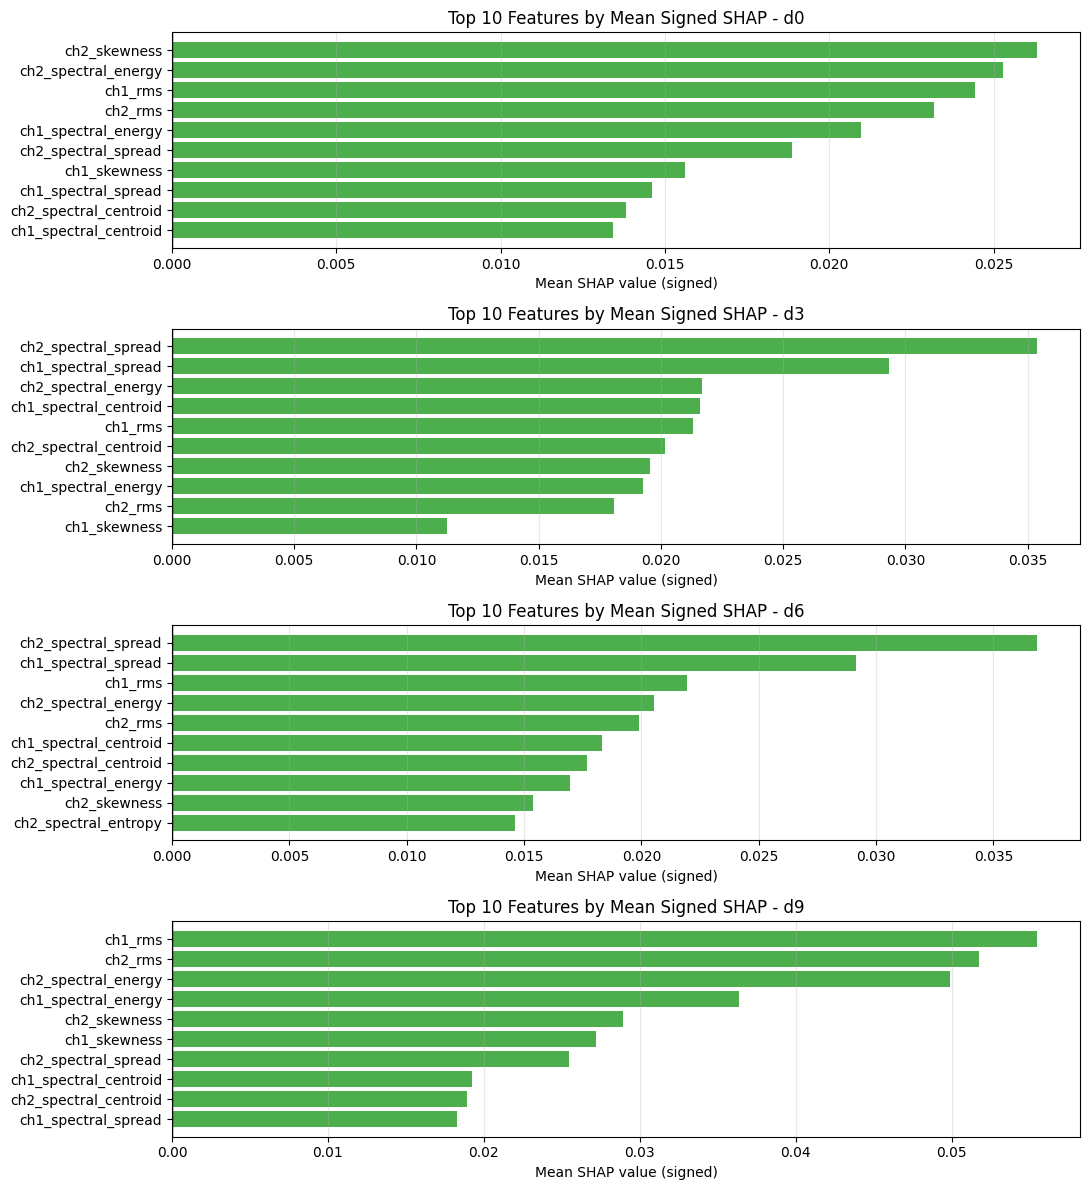

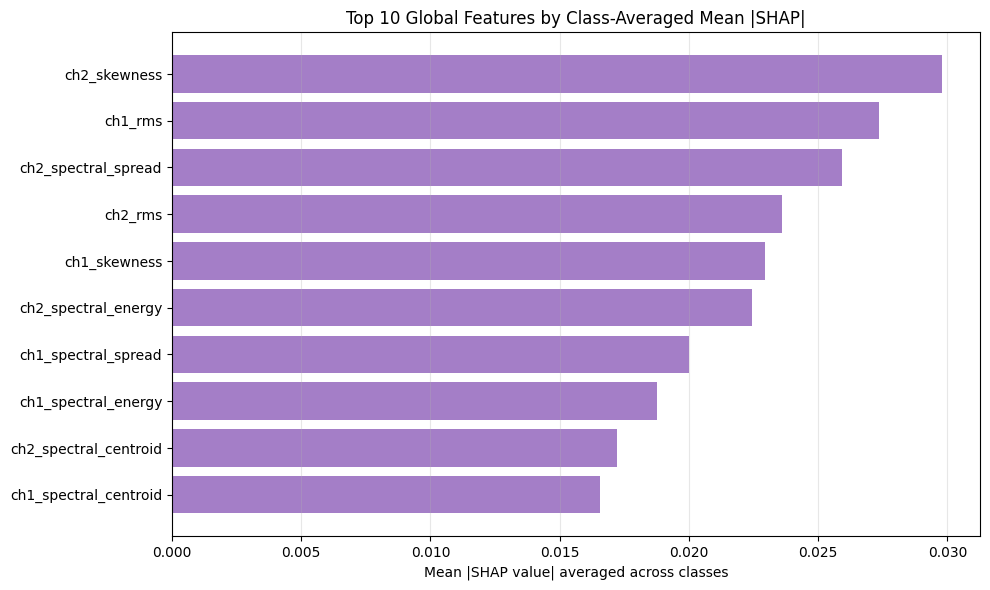


=== Per-class Top Features (Mean |SHAP|) ===

d0
 1. ch2_skewness: 0.031382
 2. ch1_rms: 0.021843
 3. ch2_spectral_energy: 0.016385
 4. ch1_skewness: 0.016367
 5. ch2_rms: 0.015902
 6. ch2_spectral_spread: 0.015257
 7. ch1_spectral_energy: 0.014893
 8. ch1_spectral_centroid: 0.013817
 9. ch2_spectral_centroid: 0.013100
10. ch1_spectral_spread: 0.011892

d3
 1. ch2_skewness: 0.036157
 2. ch2_spectral_spread: 0.028913
 3. ch1_rms: 0.024515
 4. ch1_spectral_spread: 0.023356
 5. ch1_skewness: 0.021403
 6. ch2_spectral_energy: 0.020843
 7. ch2_rms: 0.020409
 8. ch1_spectral_centroid: 0.019867
 9. ch1_spectral_energy: 0.018822
10. ch2_spectral_centroid: 0.018738

d6
 1. ch2_spectral_spread: 0.035503
 2. ch1_spectral_spread: 0.028069
 3. ch1_rms: 0.024634
 4. ch1_skewness: 0.023890
 5. ch2_skewness: 0.023519
 6. ch2_rms: 0.022587
 7. ch2_spectral_energy: 0.020223
 8. ch2_spectral_centroid: 0.016639
 9. ch1_spectral_centroid: 0.016169
10. ch1_spectral_energy: 0.015725

d9
 1. ch1_rms: 0.03843

In [10]:
# SHAP Analysis
import numpy as np
import matplotlib.pyplot as plt

print("=== SHAP Analysis ===")
num_folds = len(shap_res["shap_values_per_fold"])
print(f"Number of CV folds: {num_folds}")

# Detect SHAP output format
first_shap = shap_res["shap_values_per_fold"][0]["shap_values"]
is_multiclass = isinstance(first_shap, list) or (hasattr(first_shap, "shape") and len(np.asarray(first_shap).shape) == 3)

if is_multiclass:
    if isinstance(first_shap, list):
        n_classes = len(first_shap)
    else:
        n_classes = np.asarray(first_shap).shape[2]
    print(f"Classification type: Multiclass ({n_classes} classes)")
else:
    n_classes = 1
    print("Classification type: Binary")

# Resolve display names for classes
unique_labels = np.asarray(eval_res.get("unique_labels", np.arange(n_classes)))
if unique_labels.size != n_classes:
    unique_labels = np.arange(n_classes)
label_to_class = create_label_to_class_map(win_metadata)
class_names = [label_to_class.get(int(lbl), f"Class {int(lbl)}") for lbl in unique_labels]
labels_arr = np.asarray(labels)

def _extract_class_shap(shap_values, class_idx):
    if isinstance(shap_values, list):
        return np.asarray(shap_values[class_idx])
    shap_arr = np.asarray(shap_values)
    if shap_arr.ndim == 3:
        return shap_arr[..., class_idx]
    return shap_arr

# Aggregate OOF SHAP values across folds per class
mean_abs_shap_per_class = []
mean_signed_shap_per_class = []

for class_idx in range(n_classes):
    src_class_idx = class_idx if is_multiclass else 0
    target_label = unique_labels[class_idx]

    shap_vals_class_all = []
    shap_vals_class_signed = []

    for fold in shap_res["shap_values_per_fold"]:
        shap_matrix = _extract_class_shap(fold["shap_values"], src_class_idx)
        shap_vals_class_all.append(shap_matrix)

        val_idx = np.asarray(fold["val_idx"])
        if shap_matrix.shape[0] != val_idx.shape[0]:
            raise ValueError(
                f"SHAP samples ({shap_matrix.shape[0]}) do not match val_idx length ({val_idx.shape[0]})."
            )
        y_true_fold = labels_arr[val_idx]
        class_mask = y_true_fold == target_label
        if np.any(class_mask):
            shap_vals_class_signed.append(shap_matrix[class_mask])

    all_shap_class = np.concatenate(shap_vals_class_all, axis=0)
    mean_abs_shap_per_class.append(np.mean(np.abs(all_shap_class), axis=0))

    if len(shap_vals_class_signed) == 0:
        raise ValueError(
            f"No samples found for class label {target_label} when computing signed SHAP means."
        )
    signed_shap_class = np.concatenate(shap_vals_class_signed, axis=0)
    mean_signed_shap_per_class.append(np.mean(signed_shap_class, axis=0))

mean_abs_shap_per_class = np.asarray(mean_abs_shap_per_class)
mean_signed_shap_per_class = np.asarray(mean_signed_shap_per_class)

# Keep this name for downstream cells that already use it
mean_shap_per_class = mean_abs_shap_per_class

top_n = min(10, mean_abs_shap_per_class.shape[1])

# 1) Mean absolute SHAP bars (importance ranking, per class)
fig, axes = plt.subplots(n_classes, 1, figsize=(11, max(4, 3 * n_classes)), squeeze=False)
for class_idx in range(n_classes):
    ax = axes[class_idx, 0]
    top_idx = np.argsort(mean_abs_shap_per_class[class_idx])[::-1][:top_n]
    top_vals = mean_abs_shap_per_class[class_idx][top_idx]
    top_feats = [feature_names[i] for i in top_idx]
    y_pos = np.arange(len(top_feats))

    ax.barh(y_pos, top_vals, color="tab:blue", alpha=0.85)
    ax.set_yticks(y_pos)
    ax.set_yticklabels(top_feats)
    ax.invert_yaxis()
    ax.set_xlabel("Mean |SHAP value|")
    ax.set_title(f"Top {top_n} Features by Mean |SHAP| - {class_names[class_idx]}")
    ax.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.show()

# 2) Mean signed SHAP bars (directional average, per class)
fig, axes = plt.subplots(n_classes, 1, figsize=(11, max(4, 3 * n_classes)), squeeze=False)
for class_idx in range(n_classes):
    ax = axes[class_idx, 0]
    # Rank by absolute signed mean so both positive and negative drivers appear
    top_idx = np.argsort(np.abs(mean_signed_shap_per_class[class_idx]))[::-1][:top_n]
    top_vals = mean_signed_shap_per_class[class_idx][top_idx]
    top_feats = [feature_names[i] for i in top_idx]
    y_pos = np.arange(len(top_feats))
    colors = ["tab:green" if v >= 0 else "tab:red" for v in top_vals]

    ax.barh(y_pos, top_vals, color=colors, alpha=0.85)
    ax.axvline(0.0, color="black", linewidth=1.0)
    ax.set_yticks(y_pos)
    ax.set_yticklabels(top_feats)
    ax.invert_yaxis()
    ax.set_xlabel("Mean SHAP value (signed)")
    ax.set_title(f"Top {top_n} Features by Mean Signed SHAP - {class_names[class_idx]}")
    ax.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.show()

# 3) Average across classes (global multiclass overview)
avg_abs_shap_all_classes = np.mean(mean_abs_shap_per_class, axis=0)
avg_signed_shap_all_classes = np.mean(mean_signed_shap_per_class, axis=0)

top_idx_global = np.argsort(avg_abs_shap_all_classes)[::-1][:top_n]
top_vals_global = avg_abs_shap_all_classes[top_idx_global]
top_feats_global = [feature_names[i] for i in top_idx_global]
y_pos_global = np.arange(len(top_feats_global))

plt.figure(figsize=(10, 6))
plt.barh(y_pos_global, top_vals_global, color="tab:purple", alpha=0.85)
plt.yticks(y_pos_global, top_feats_global)
plt.gca().invert_yaxis()
plt.xlabel("Mean |SHAP value| averaged across classes")
plt.title(f"Top {top_n} Global Features by Class-Averaged Mean |SHAP|")
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

# Mirrored text summary for logs/quick comparison
print("\n=== Per-class Top Features (Mean |SHAP|) ===")
for class_idx in range(n_classes):
    top_idx = np.argsort(mean_abs_shap_per_class[class_idx])[::-1][:top_n]
    print(f"\n{class_names[class_idx]}")
    for rank, feat_idx in enumerate(top_idx, start=1):
        print(f"{rank:2d}. {feature_names[feat_idx]}: {mean_abs_shap_per_class[class_idx][feat_idx]:.6f}")

print("\n=== Per-class Top Features (Mean Signed SHAP) ===")
for class_idx in range(n_classes):
    top_idx = np.argsort(np.abs(mean_signed_shap_per_class[class_idx]))[::-1][:top_n]
    print(f"\n{class_names[class_idx]}")
    for rank, feat_idx in enumerate(top_idx, start=1):
        print(f"{rank:2d}. {feature_names[feat_idx]}: {mean_signed_shap_per_class[class_idx][feat_idx]:+.6f}")

print("\n=== Global Top Features (Class-Averaged Mean |SHAP|) ===")
for rank, feat_idx in enumerate(top_idx_global, start=1):
    print(f"{rank:2d}. {feature_names[feat_idx]}: {avg_abs_shap_all_classes[feat_idx]:.6f}")

print(f"Mean absolute class-averaged signed SHAP magnitude: {np.mean(np.abs(avg_signed_shap_all_classes)):.6f}")
print(f"Total features analyzed: {mean_abs_shap_per_class.shape[1]}")

In [4]:
import numpy as np
import matplotlib.pyplot as plt

def _infer_shap_layout(shap_values):
    """Infer SHAP container format and class count from one fold output."""
    if isinstance(shap_values, list):
        if len(shap_values) == 0:
            raise ValueError("SHAP list format is empty.")
        return {"format": "list", "n_classes": len(shap_values)}

    arr = np.asarray(shap_values)
    if arr.ndim == 3:
        n_classes = arr.shape[2]
        if n_classes <= 1:
            return {"format": "binary3d", "n_classes": 1}
        return {"format": "array3d", "n_classes": n_classes}
    if arr.ndim == 2:
        return {"format": "array2d", "n_classes": 1}
    raise ValueError(f"Unsupported SHAP format with shape {arr.shape}.")

def _extract_class_shap_matrix(shap_values, class_idx, layout):
    """Return SHAP matrix with shape (n_samples, n_features) for one class."""
    fmt = layout["format"]
    if fmt == "list":
        if class_idx < 0 or class_idx >= len(shap_values):
            raise ValueError(f"class_idx={class_idx} is out of range for {len(shap_values)} classes.")
        return np.asarray(shap_values[class_idx])

    arr = np.asarray(shap_values)
    if fmt == "array3d":
        if class_idx < 0 or class_idx >= arr.shape[2]:
            raise ValueError(f"class_idx={class_idx} is out of range for {arr.shape[2]} classes.")
        return arr[..., class_idx]
    if fmt == "binary3d":
        if class_idx != 0:
            raise ValueError("Binary SHAP output supports only class_idx=0.")
        return arr[..., 0]
    if fmt == "array2d":
        if class_idx != 0:
            raise ValueError("Binary SHAP output supports only class_idx=0.")
        return arr

    raise ValueError(f"Unsupported SHAP format: {fmt}.")

def _resolve_class_idx(class_name, class_names):
    """Map class string to class index and fail loudly if not found."""
    if class_name not in class_names:
        available = ", ".join(class_names)
        raise ValueError(f"Unknown class_name='{class_name}'. Available classes: {available}")
    return int(class_names.index(class_name))

def _resolve_feature_idx(feature_name, feature_names):
    """Map feature string to feature index and fail loudly if not found."""
    if feature_name not in feature_names:
        preview = ", ".join(feature_names[:12])
        if len(feature_names) > 12:
            preview += ", ..."
        raise ValueError(
            f"Unknown feature_name='{feature_name}'. Available feature examples: {preview}"
        )
    return int(feature_names.index(feature_name))

def _collect_scatter_data(shap_res, features, class_idx, feature_idx, layout=None):
    """Collect aligned feature values and SHAP values across validation folds."""
    folds = shap_res.get("shap_values_per_fold", [])
    if len(folds) == 0:
        raise ValueError("shap_res['shap_values_per_fold'] is empty.")
    if feature_idx < 0 or feature_idx >= features.shape[1]:
        raise ValueError(f"feature_idx={feature_idx} is out of range [0, {features.shape[1] - 1}].")

    if layout is None:
        layout = _infer_shap_layout(folds[0]["shap_values"])

    x_parts = []
    y_parts = []
    for fold_no, fold in enumerate(folds):
        val_idx = np.asarray(fold["val_idx"])
        shap_matrix = _extract_class_shap_matrix(fold["shap_values"], class_idx, layout)

        if shap_matrix.ndim != 2:
            raise ValueError(f"Fold {fold_no}: expected 2D SHAP matrix, got shape {shap_matrix.shape}.")
        if shap_matrix.shape[0] != len(val_idx):
            raise ValueError(
                f"Fold {fold_no}: SHAP rows ({shap_matrix.shape[0]}) != len(val_idx) ({len(val_idx)})."
            )
        if shap_matrix.shape[1] != features.shape[1]:
            raise ValueError(
                f"Fold {fold_no}: SHAP features ({shap_matrix.shape[1]}) != features columns ({features.shape[1]})."
            )

        x_parts.append(features[val_idx, feature_idx])
        y_parts.append(shap_matrix[:, feature_idx])

    return np.concatenate(x_parts, axis=0), np.concatenate(y_parts, axis=0)

def plot_shap_scatter(class_name, feature_name, use_abs=False, alpha=0.6, figsize=(8, 6)):
    """Plot SHAP scatter by class name and feature name.

    Example: plot_shap_scatter(class_name="d0", feature_name="ch3_ptp")
    """
    if not isinstance(class_name, str) or class_name.strip() == "":
        raise ValueError("class_name must be a non-empty string.")
    if not isinstance(feature_name, str) or feature_name.strip() == "":
        raise ValueError("feature_name must be a non-empty string.")

    resolved_class_names = class_names if "class_names" in globals() else labels_order
    class_idx = _resolve_class_idx(class_name=class_name, class_names=list(resolved_class_names))
    feature_idx = _resolve_feature_idx(feature_name=feature_name, feature_names=list(feature_names))

    first_shap = shap_res["shap_values_per_fold"][0]["shap_values"]
    layout = _infer_shap_layout(first_shap)
    if layout["n_classes"] == 1 and class_idx != 0:
        raise ValueError("Binary SHAP output has only one class; use class_name of index 0.")

    x_vals, y_vals = _collect_scatter_data(
        shap_res=shap_res,
        features=features,
        class_idx=class_idx,
        feature_idx=feature_idx,
        layout=layout,
    )

    y_plot = np.abs(y_vals) if use_abs else y_vals
    y_label = "|SHAP Value|" if use_abs else "SHAP Value"

    plt.figure(figsize=figsize)
    plt.scatter(x=x_vals, y=y_plot, alpha=alpha)
    plt.xlabel(f"Feature Value: {feature_name}")
    plt.ylabel(y_label)
    plt.title(f"SHAP Scatter - {class_name} | {feature_name}")
    plt.grid(True, alpha=0.3)
    plt.show()

    return {
        "class_name": class_name,
        "feature_name": feature_name,
        "class_idx": class_idx,
        "feature_idx": feature_idx,
        "n_points": int(len(x_vals)),
    }

In [5]:
print("Available classes:", class_names)
print("Available features:", feature_names[:15])

Available classes: ['d0', 'd3', 'd6', 'd9']
Available features: ['ch1_rms', 'ch1_ptp', 'ch1_skewness', 'ch1_kurtosis', 'ch1_crest_factor', 'ch1_form_factor', 'ch2_rms', 'ch2_ptp', 'ch2_skewness', 'ch2_kurtosis', 'ch2_crest_factor', 'ch2_form_factor', 'frequency_hz', 'load']


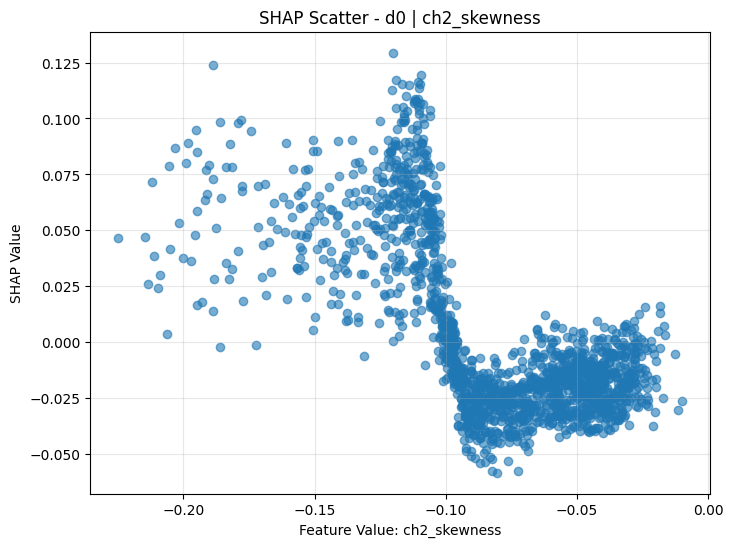

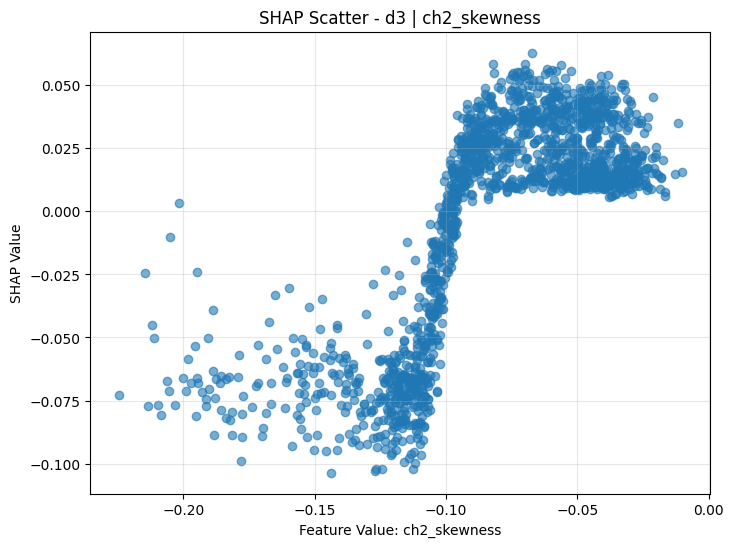

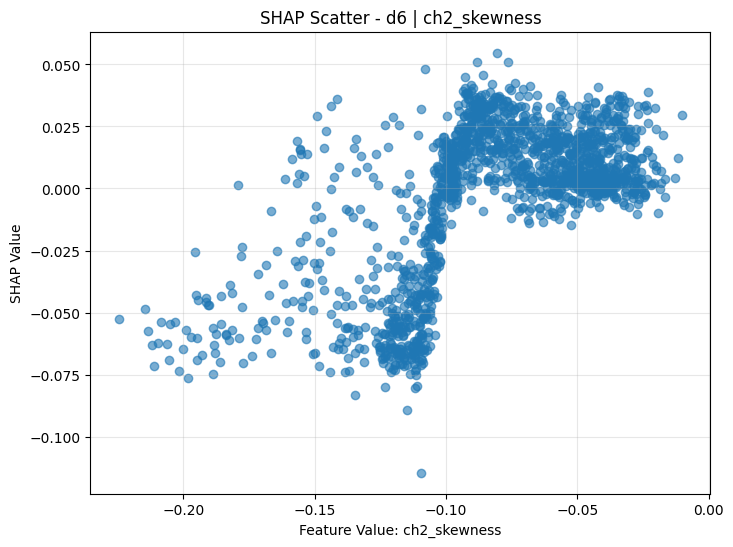

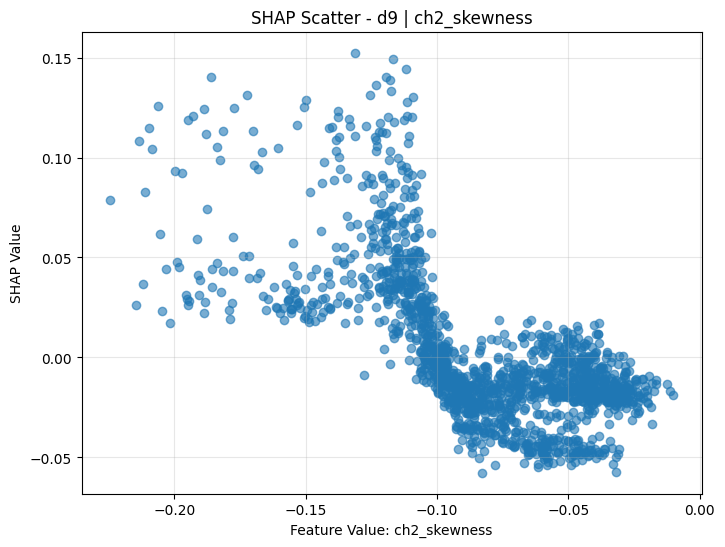

{'class_name': 'd0', 'feature_name': 'ch2_skewness', 'class_idx': 0, 'feature_idx': 14, 'n_points': 1600}


In [12]:
summary = plot_shap_scatter(class_name="d0", feature_name="ch2_skewness")
plot_shap_scatter(class_name="d3", feature_name="ch2_skewness")
plot_shap_scatter(class_name="d6", feature_name="ch2_skewness")
plot_shap_scatter(class_name="d9", feature_name="ch2_skewness")
print(summary)